In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv
import datetime
import os
import mplfinance as mpf
import re
import utils

In [2]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [14]:
query_min = "SELECT * FROM gold.active_1min ORDER BY bar_date, bar_time"
query_5min = "SELECT * FROM gold.active_5min ORDER BY bar_date, bar_time"
query_15min = "SELECT * FROM gold.active_15min ORDER BY bar_date, bar_time"
df_min = pd.read_sql(query_min,engine)
df_5min = pd.read_sql(query_5min,engine)
df_15min = pd.read_sql(query_15min,engine)

Swing Table

In [15]:
def display_swings(df,bucket,timeframe):
    df_swing= utils.get_swings(df)
    df_agg, df_agg_IQR = utils.aggregate_by_time(df_swing,'bucket_'+bucket+'min','profit')
    utils.bar_by_time(df_agg,'count',timeframe+' Minute Interval - '+bucket+' Minute Time Frame','Number of Swings')
    utils.bar_by_time(df_agg,'mean',timeframe+' Minute Interval - '+bucket+' Minute Time Frame','Average Swing Magnitude')
    utils.bar_by_time(df_agg,'std',timeframe+' Minute Interval - '+bucket+' Minute Time Frame','STD of Swing Magnitude')
    utils.bar_by_time(df_agg_IQR,'mean',timeframe+' Minute Interval - '+bucket+' Minute Time Frame','Average IQR Swing Magnitude')
    utils.bar_by_time(df_agg_IQR,'std',timeframe+' Minute Interval - '+bucket+' Minute Time Frame','STD of IQR Swing Magnitude')

1 Minute Chart

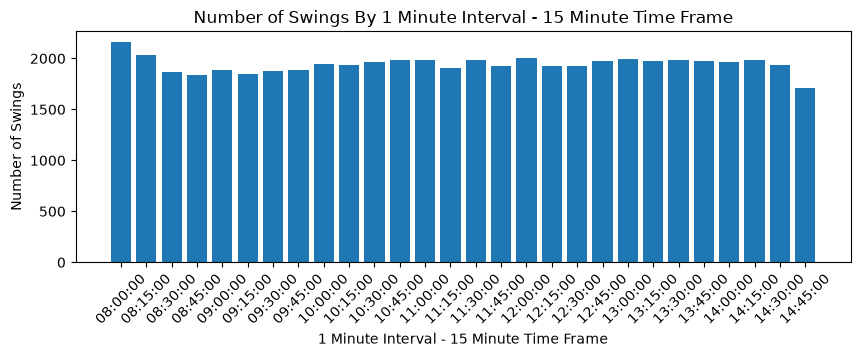

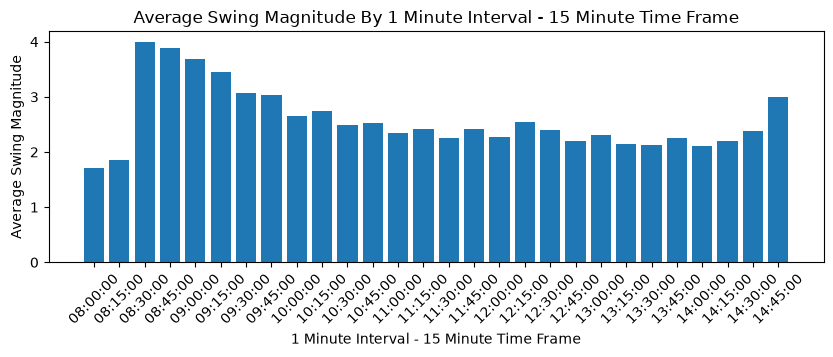

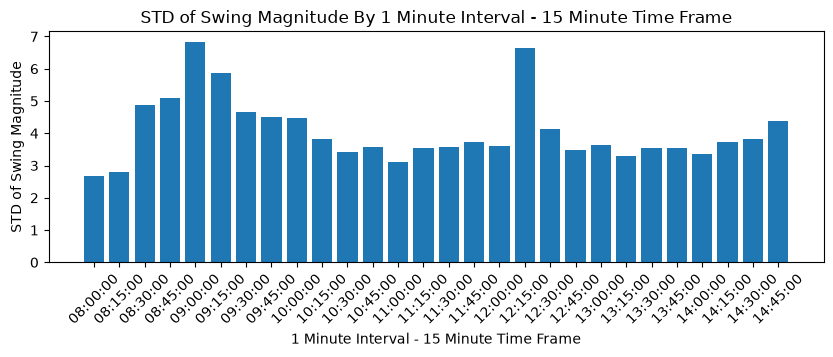

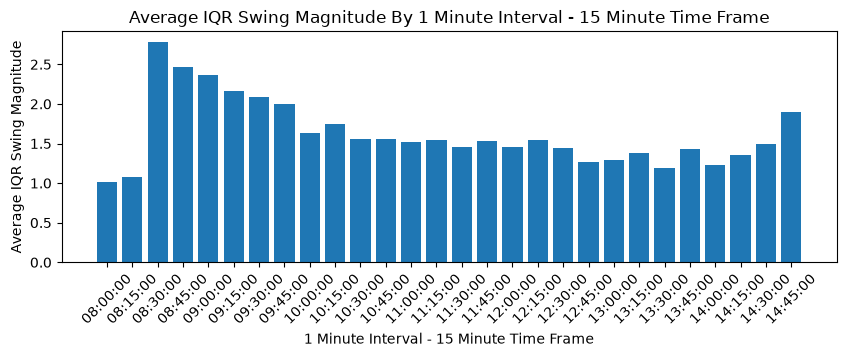

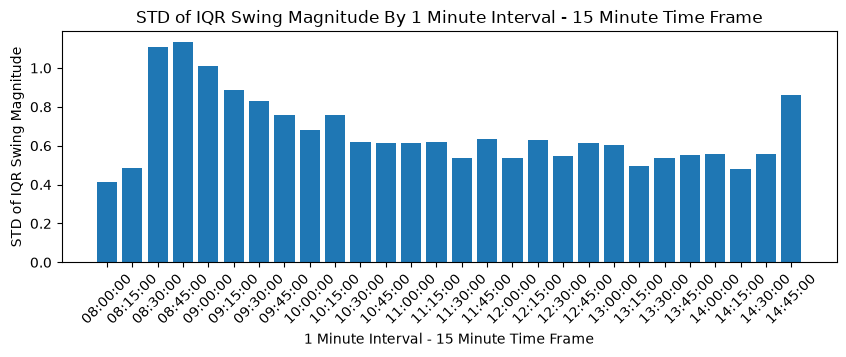

In [17]:
display_swings(df_min,'15','1')

5 Minute Chart

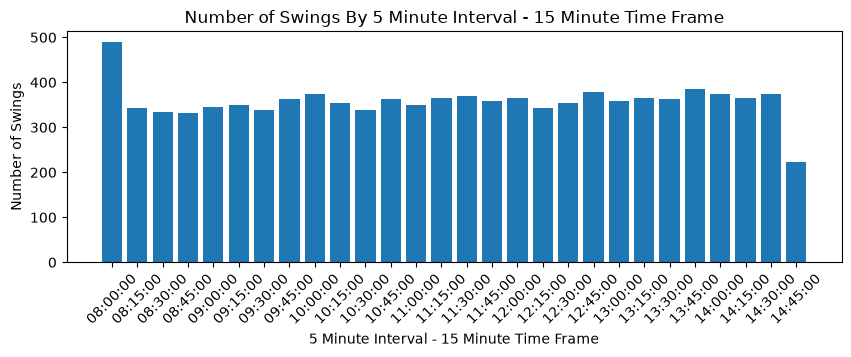

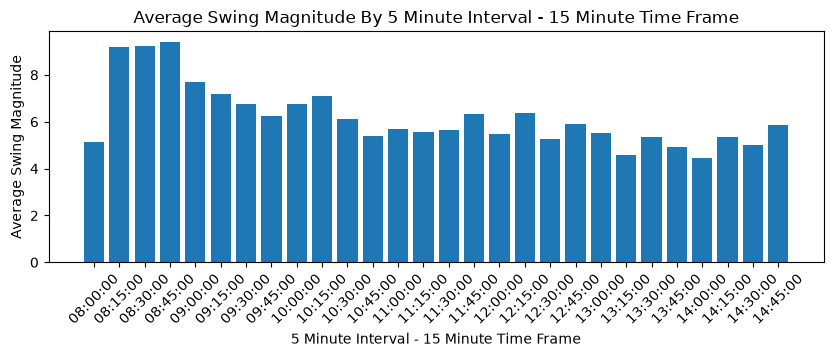

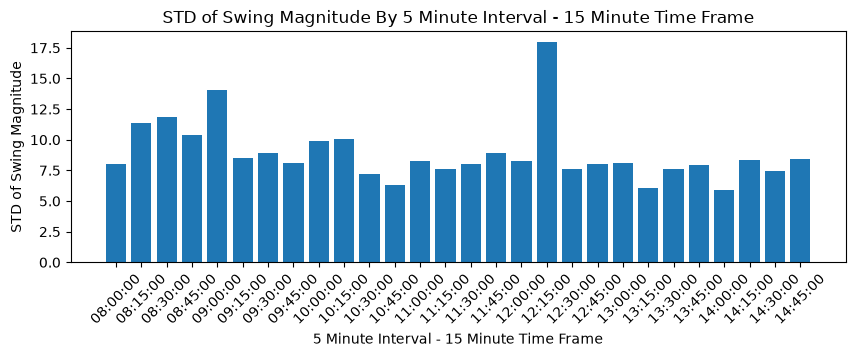

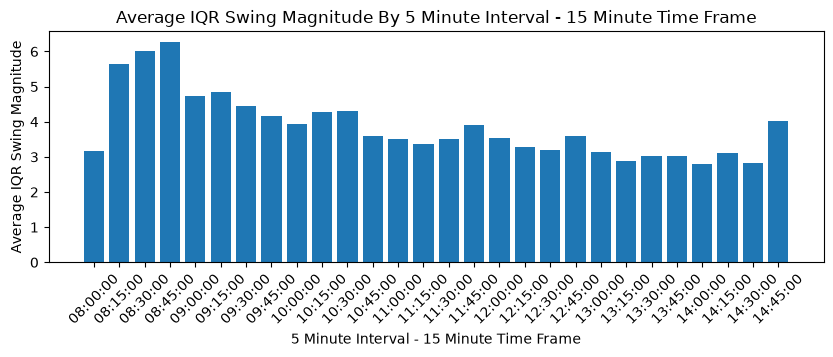

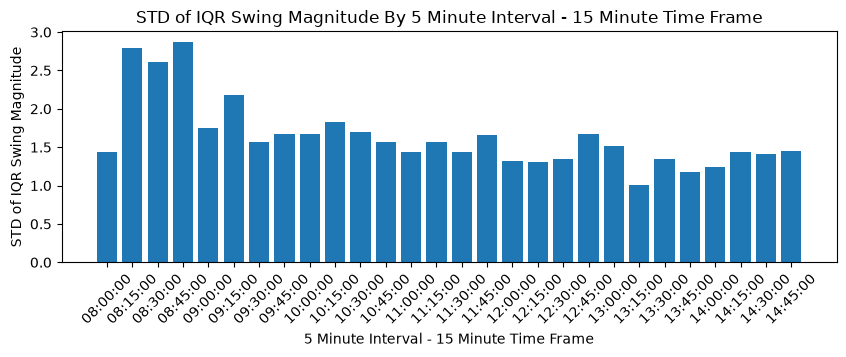

In [18]:
display_swings(df_5min,'15','5')

15 Minute Chart

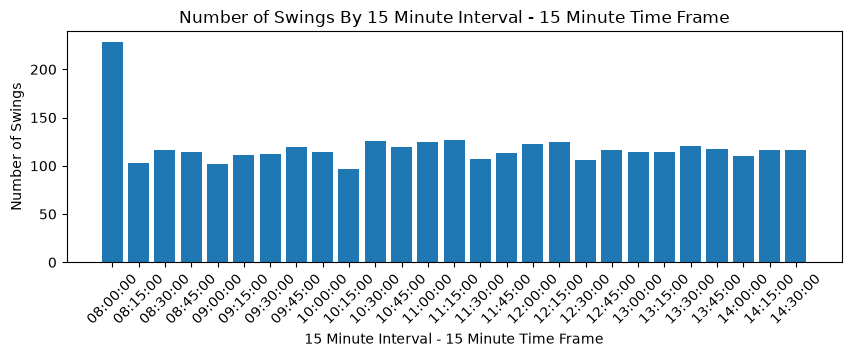

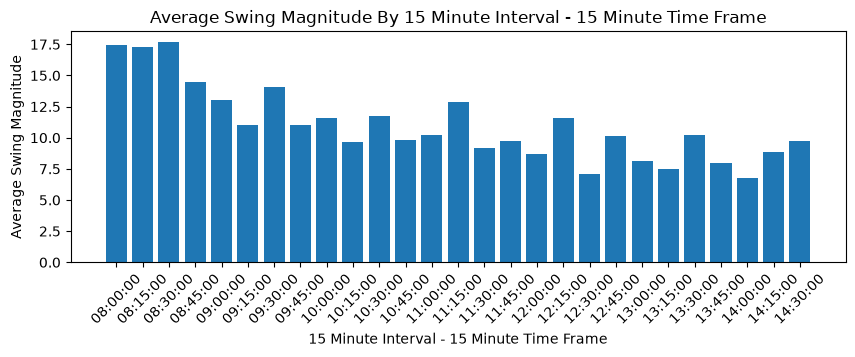

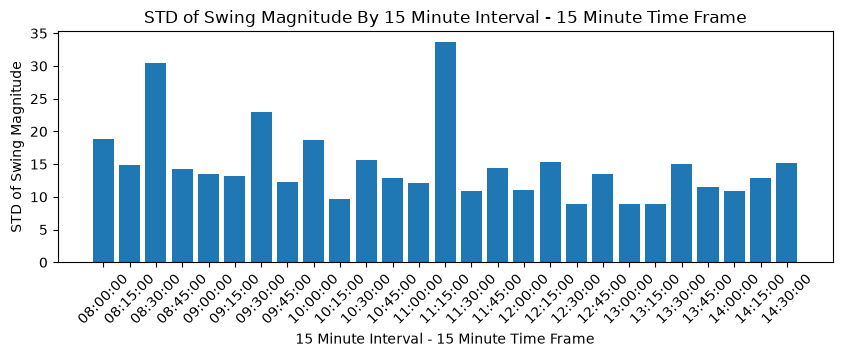

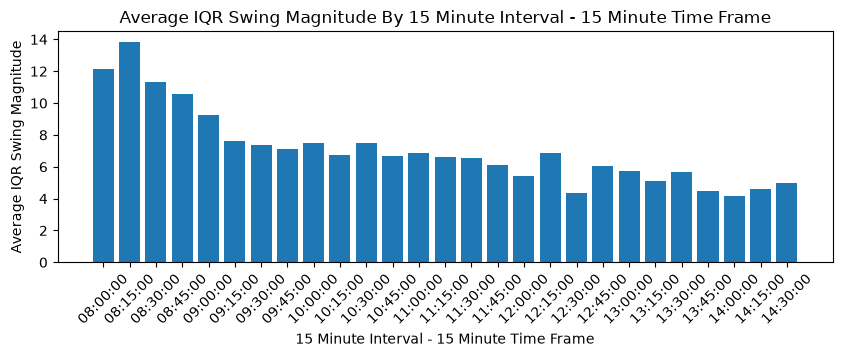

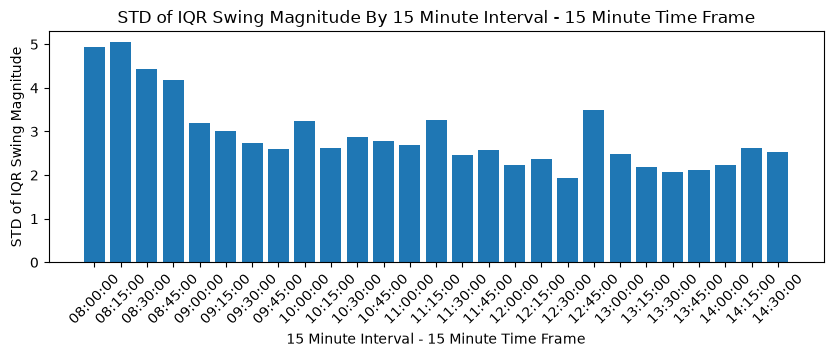

In [19]:
display_swings(df_15min,'15','15')